# CT LAB: Simulating and Reconstructing Tomography Data

Authors: L. Calatroni, A. Sebastiani (MaLGa, Unige)

Mini-course "Computational Imaging & Learning" - MSc in Data Science, University of Padua, Italy.

Welcome to the CT computational lab. The core of the **Computed Tomography (CT)** problem lies in recovering a hidden image from a set of projections. While a single X-ray provides only a flattened shadow of the object of interest, CT measures the total X-ray attenuation along a certain number of different paths.

The goal is to reconstruct precise internal cross-sections, the raw data—represented as a sinogram—consists of discrete, noisy line integrals corrupted by noise.  The objective is to formulate a rigorous forward model of the scanning process based on the discrete Radon transform and solve the resulting ill-posed inverse problem to recover the tissue attenuation map. We will utilize the `deepinv` library to implement optimization algorithms for Maximum Likelihood and Maximum a Posteriori estimation.

In [35]:
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Importing images and basic operations
from skimage.data import shepp_logan_phantom
from skimage.color import rgb2gray
from skimage.transform import resize

import deepinv as dinv
import torch

# Check if GPU is available
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
print(f'Device is {device}')

# Use parallel dataloader if using a GPU to fasten training.
num_workers = 5 if torch.cuda.is_available() else 0

dtype = torch.float32
circle = False

MSE = dinv.loss.metric.MSE()
PSNR = dinv.loss.metric.PSNR()
SSIM = dinv.loss.metric.SSIM()

Selected GPU 0 with 5030.625 MiB free memory
Device is cuda:0


# Image loading

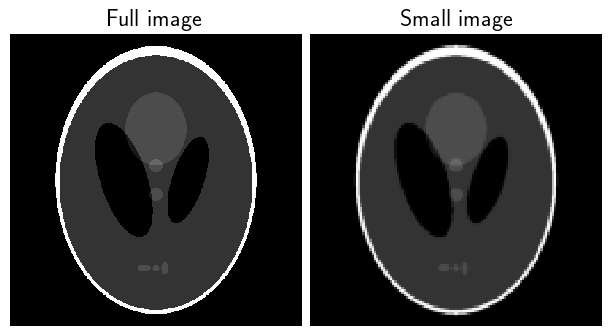

In [36]:
# A benchmark image for medical imaging problems
u_SL = shepp_logan_phantom()

# Reshape the image to a smaller size (with piecewise constant interpolation)
N_SL_small = 128
u_SL_small = resize(u_SL, (N_SL_small,N_SL_small), order=0,preserve_range=True,anti_aliasing=True)


u_SL = torch.tensor(u_SL).unsqueeze(0).unsqueeze(0).to(dtype).to(device)
u_SL_small = torch.tensor(u_SL_small).unsqueeze(0).unsqueeze(0).to(dtype).to(device)


dinv.utils.plot([u_SL,u_SL_small], ['Full image', 'Small image'], figsize=(6,4))

# **Radon Transform - Computed Tomography**

Collect integrals of an image $f$ along straight lines:

$$ \begin{aligned} \mathbf{y}(\boldsymbol{\theta},\rho) &= \int_{L_{\boldsymbol{\theta},\rho}}~u~d\sigma
\end{aligned} \qquad \boldsymbol{\theta} \in \R^2,~ \| \boldsymbol{\theta}\|=1, \quad \rho \in \mathbb{R}_+$$

($\mathbf{y}$ is usually referred to as the *sinogram* of $u$ and $L_{\boldsymbol{\theta},\rho} =  \left\{ \mathbf{x}: \mathbf{x}\cdot \boldsymbol{\theta} = \rho \right\}$)

Subsampling can be motivated by physical limitations in the acquisition procedure and by the goal of reducing the exposition to X-rays
*   **sparse** angles: (uniformly) subsample the angle $\omega$ such that $\boldsymbol{\theta} = (\cos\omega, \sin\omega)$.
*   **limited** angles: acquire angles only in a limited wedge $[\omega_{\text{min}},\omega_{\text{max}}]$

# Defining the Forward model

In [37]:
# define a forward model with 180 angles in the full angular range [0, 180]
img_width = N_SL_small
N_theta_full = 180
theta_full = np.linspace(0, 180, N_theta_full, endpoint=False)
theta_full = torch.tensor(theta_full).to(device)

tomo_full = dinv.physics.Tomography(angles=theta_full, img_width=img_width, circle=circle, device=device)

sinogram_full = tomo_full(u_SL_small)

/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/physics/tomography.py:187: UserWarning: The default value of `normalize` is not specified and will be automatically set to `True`. Set `normalize` explicitly to `True` or `False` to avoid this warning.
  warn(
/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/physics/forward.py:487: UserWarning: Following torch.nn.Module's design, the 'device' attribute is deprecated and will be removed in a future version. To move the module's buffers/parameters to a different device, use the `to()` method.
  warnings.warn(


In [38]:
# define a sparse angle CT forward model with 36 angles in the full angular range [0, 180]
N_theta_sparse = 36
theta_sparse = np.linspace(0, 180, N_theta_sparse, endpoint=False)
theta_sparse = torch.tensor(theta_sparse).to(device)

tomo_sparse = dinv.physics.Tomography(angles=theta_sparse, img_width=img_width, circle=circle, device=device)

sinogram_sparse = tomo_sparse(u_SL_small)

In [39]:
# define a limited angle CT forward model within the angular range [30, 150]
Theta_min = 30
Theta_max = 150
N_theta_lim = np.round((Theta_max-Theta_min)/180*N_theta_full).astype('int')
theta_limited = np.linspace(Theta_min, Theta_max, N_theta_lim, endpoint=False)
theta_limited = torch.tensor(theta_limited).to(device)

tomo_limited = dinv.physics.Tomography(angles=theta_limited, img_width=img_width, circle=circle, device=device)

sinogram_limited = tomo_limited(u_SL_small)

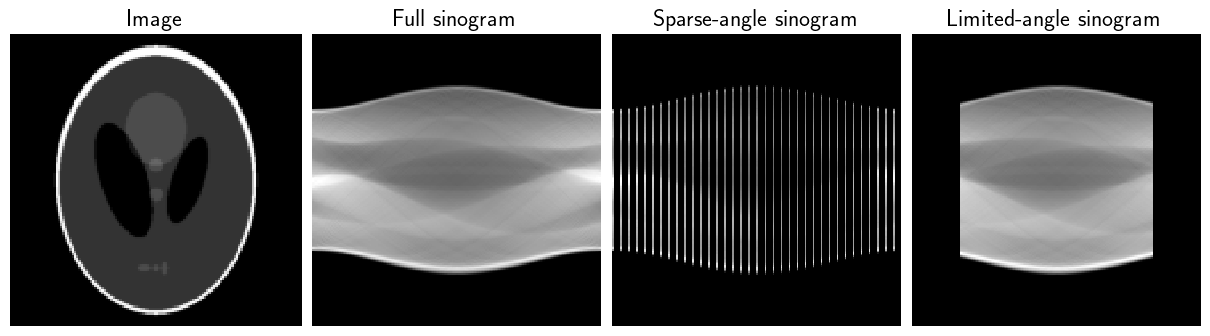

In [40]:
# fill the entire sinograms with the limited data sinograms
fill_sinogram_sparse = torch.zeros_like(sinogram_full)
fill_sinogram_sparse[..., theta_sparse.int()] = sinogram_sparse

fill_sinogram_limited = torch.zeros_like(sinogram_full)
fill_sinogram_limited[..., theta_limited.int()] = sinogram_limited

img_list = [u_SL_small, sinogram_full, fill_sinogram_sparse, fill_sinogram_limited]
title_list = ['Image', 'Full sinogram', 'Sparse-angle sinogram', 'Limited-angle sinogram']

dinv.utils.plot(img_list, title_list, figsize=(12,4))

In [41]:
# For adding Gaussian noise
class GaussianNoiseCT(dinv.physics.GaussianNoise):
  def __init__(
        self,
        sigma: float | torch.Tensor = 0.1,
        rng: torch.Generator | None = None,
    ):
        super().__init__(sigma=sigma, rng=rng)

  def forward(self, x, sigma=None, seed=None, **kwargs):
        self.update_parameters(sigma=sigma, **kwargs)
        self.to(x.device)
        return (
            x
            + torch.max(torch.abs(x))*self.randn_like(x, seed=seed)
            * self.sigma[(...,) + (None,) * (x.dim() - 1)]
        )

# **Näive inversion**

An inverse problem can be representing as recovering $f$ from
$$ y = \operatorname{noise}(A(u))$$
Let $A$ be linear (and additive noise): in the discrete formulation, this reduces to
$$ y = \mathbf{A} u + ϵ, \quad u \in \mathbb{R}^n, \epsilon \in \mathbb{R}^m, \mathbf{A} \in \mathbb{R}^{m \times n} $$

Easy idea to solve it:
$$ u_{\text{naive}} = \mathbf{A}^{-1} y$$

For the Radon tranform, we used the Filtered Back-Projection (FBP) to ``invert'' the measurements.

**TASK 1: Experiment with the Forward Model**

Change the variables in the cells above and re-run them to see the effects!
* **Change the phisyics:** Modify `tomo_exp` (physics) to see how the size of the sinogram changes.
* **Change the noise:** Adjust the `nl` parameter. How does the image look when the noise level increase?
* **Observe the reconstructions:** Compare the reconstructions obtained with the FBP under different acquisition geometries.

In [42]:
# Selection operator for experiments, select any of the previous ones
tomo_exp = tomo_sparse  # try tomo_full, tomo_sparse, or tomo_limited

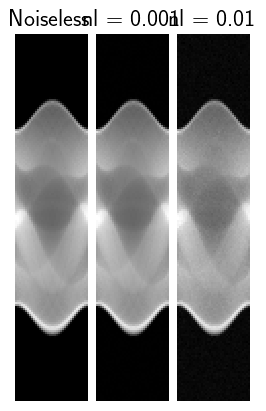

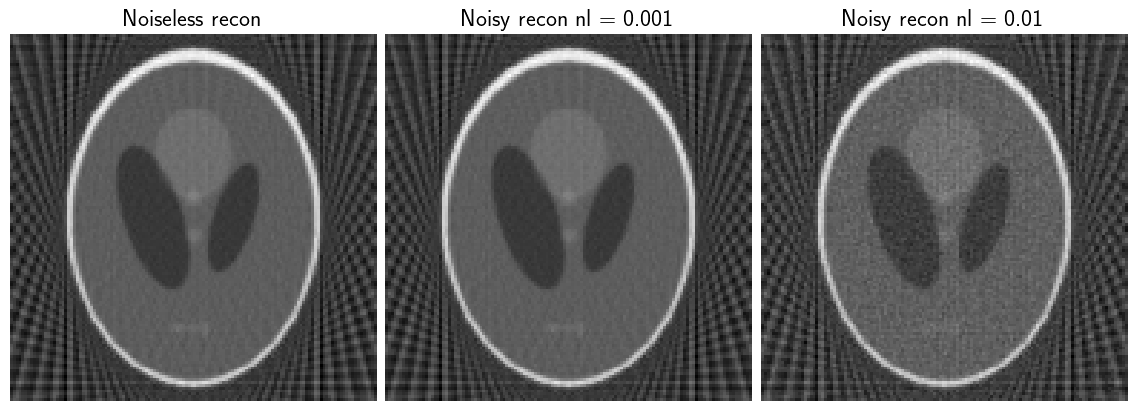

In [43]:
sinogram = tomo_exp(u_SL_small)
u_rec = tomo_exp.fbp(sinogram)

# add noise to the sinogram with noise level 1e-3
nl1 = 1e-3
noise_ph = GaussianNoiseCT(sigma=nl1)
sinogram_noisy = noise_ph(sinogram)
# compute the FBP of the noisy sinogram
u_rec_noisy = tomo_exp.fbp(sinogram_noisy)

# add noise to the sinogram with noise level 1e-2
nl2 = 1e-2
noise_ph2 = GaussianNoiseCT(sigma=nl2)
sinogram_noisy2 = noise_ph2(sinogram)
# compute the FBP of the noisy sinogram
u_rec_noisy2 = tomo_exp.fbp(sinogram_noisy2)

titles_sino = ['Noiseless', f'nl = {nl1}', f'nl = {nl2}']
titles_rec = ['Noiseless recon', f'Noisy recon nl = {nl1}', f'Noisy recon nl = {nl2}']

dinv.utils.plot([sinogram, sinogram_noisy, sinogram_noisy2], titles_sino, figsize=(12,4))
dinv.utils.plot([u_rec, u_rec_noisy, u_rec_noisy2], titles_rec, figsize=(12,4))

In [44]:
# Compute the quality metrics for the reconstructed images
print(f'Reconstruction (noiseless sinogram)')
print(f' MSE={MSE(u_rec, u_SL_small).item():.4f}\n PSNR={PSNR(u_rec, u_SL_small).item():.2f}\n SSIM={SSIM(u_rec, u_SL_small).item():.2f}\n')

print(f'Reconstruction (sinogram noise lev {nl1})')
print(f' MSE={MSE(u_rec_noisy, u_SL_small).item():.4f}\n PSNR={PSNR(u_rec_noisy, u_SL_small).item():.2f}\n SSIM={SSIM(u_rec_noisy, u_SL_small).item():.2f}\n')

print(f'Reconstruction (sinogram noise lev {nl2})')
print(f' MSE={MSE(u_rec_noisy2, u_SL_small).item():.4f}\n PSNR={PSNR(u_rec_noisy2, u_SL_small).item():.2f}\n SSIM={SSIM(u_rec_noisy2, u_SL_small).item():.2f}\n')

Reconstruction (noiseless sinogram)
 MSE=0.0052
 PSNR=22.80
 SSIM=0.54

Reconstruction (sinogram noise lev 0.001)
 MSE=0.0053
 PSNR=22.79
 SSIM=0.54

Reconstruction (sinogram noise lev 0.01)
 MSE=0.0065
 PSNR=21.90
 SSIM=0.40



In [45]:
# Selection corrupted sinogram for the following experiments
y = sinogram_noisy2

# Unregularized Reconstruction
Ideally, we would like to solve the system $\mathbf{A} u = y$. Assembling the matrix $\mathbf{A}$ is very expensive in terms of memory.
We can avoid assembling the matrix $\mathbf{A}$!

Iterative solvers for $\mathbf{A} u = y$: e.g. minimizing $\frac{1}{2}\| \mathbf{A} u- y\|^2$ via **gradient method**:

$$
\left\{
\begin{aligned}
u^{0} & \text{ given} \\
u^{(k+1)} =&\  \mathbf{A}^T(\mathbf{A}u^{(k)}-y)
\end{aligned}
\right.
$$

This only requires the knowledge of $\mathbf{A}$ and its adjoint $\mathbf{A}^T$. The application of $\mathbf{A}$ and $\mathbf{A}^T$ can be done without matrices via operators, functions...

Reconstruction experiment
 MSE=0.0043
 PSNR=23.69
 SSIM=0.56



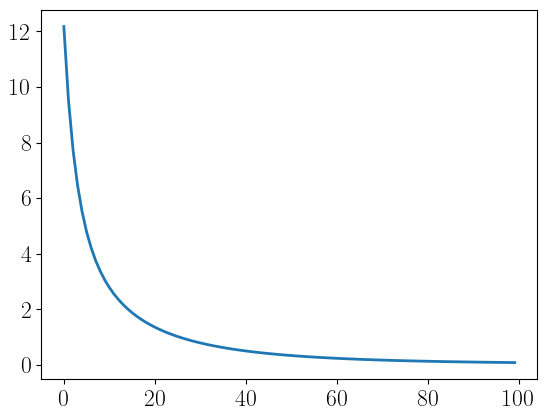

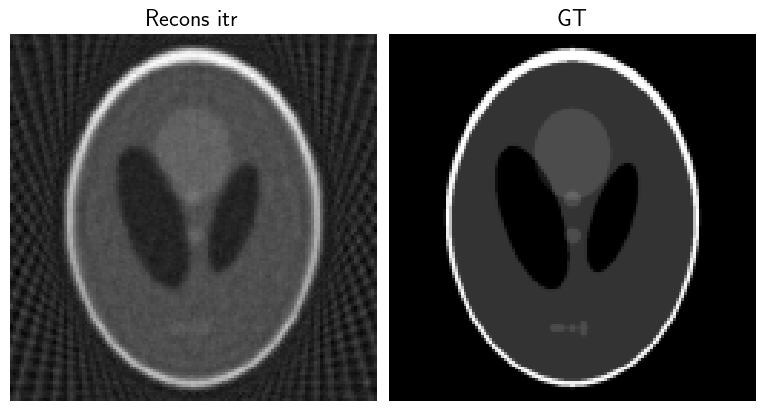

In [46]:
# Define Fidelity
fidelity = dinv.optim.data_fidelity.L2()

# Define Prior
#prior = dinv.optim.prior.Zero()
prior = dinv.optim.prior.ZeroPrior()

# Define optimizer (check https://deepinv.github.io/deepinv/api/stubs/deepinv.optim.optim_builder.html)
opt = dinv.optim.optim_builder(
    iteration="GD",
    prior=prior,
    data_fidelity=fidelity,
    max_iter=100,
    crit_conv="residual",
    thres_conv=1e-4,
    early_stop=True,
    params_algo={"stepsize": 1.0}
)
# Run
u_hat, metrics = opt(y, tomo_exp, compute_metrics=True)

print(f'Reconstruction experiment')
print(f' MSE={MSE(u_hat, u_SL_small).item():.4f}\n PSNR={PSNR(u_hat, u_SL_small).item():.2f}\n SSIM={SSIM(u_hat, u_SL_small).item():.2f}\n')

plt.plot(metrics['cost'][0])
dinv.utils.plot([u_hat, u_SL_small], ['Recons itr', 'GT'], figsize=(12,4))

# Tikhonov regularization
Penalizes solutions with large norms:

$$ u_{\alpha}^* = \arg\min_{u \in \mathbf{R}^n} \left\{ \frac{1}{2}\| A u - y \|^2 + \alpha \| u\|^2\right\}$$

(the first term of the sum measures the data fidelity and might be chosen differently according to the noise model).

The solution can be also found via first-order optimality conditions:

$$  A^T(A u_{\alpha} -y) + \alpha u_{\alpha}^* = 0 \quad ⇒ \quad (A^T A + \alpha \operatorname{Id})u_{\alpha}^* = A^T y $$

thus $u_\alpha^*$ can be found solving a linear system with symmetric, positive definite, matrix.

Reconstruction experiment
 MSE=0.0191
 PSNR=17.18
 SSIM=0.37



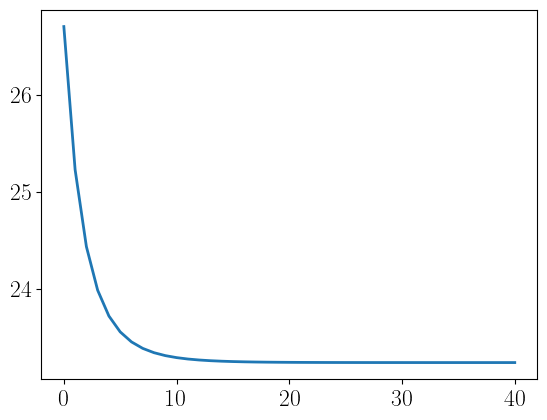

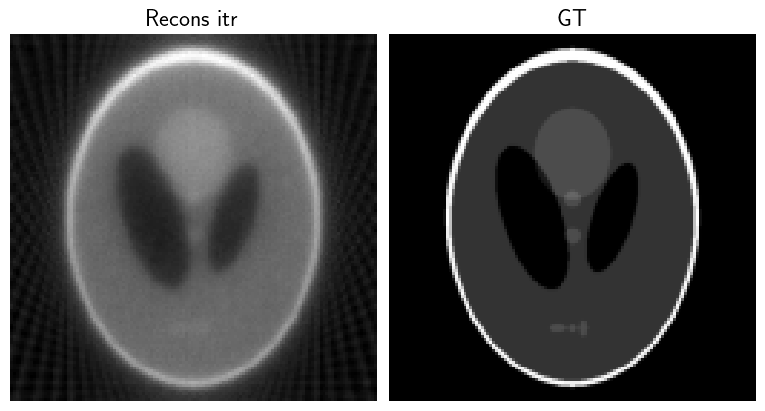

In [47]:
# Define Fidelity
fidelity = dinv.optim.data_fidelity.L2()

# Define Prior
prior = dinv.optim.Tikhonov()

# Define optimizer
opt = dinv.optim.optim_builder(
    iteration="GD",
    prior=prior,
    data_fidelity=fidelity,
    max_iter=100,
    crit_conv="residual",
    thres_conv=1e-4,
    early_stop=True,
    params_algo={"stepsize": 1.0, "lambda": 0.1}
)
## Run
u_hat, metrics = opt(y, tomo_exp, compute_metrics=True)

print(f'Reconstruction experiment')
print(f' MSE={MSE(u_hat, u_SL_small).item():.4f}\n PSNR={PSNR(u_hat, u_SL_small).item():.2f}\n SSIM={SSIM(u_hat, u_SL_small).item():.2f}\n')

plt.plot(metrics['cost'][0])
dinv.utils.plot([u_hat, u_SL_small], ['Recons itr', 'GT'], figsize=(12,4))

# Sparsity-promoting regularization (LASSO)
Penalizes solutions with large $1$-norms: this can be seen as the convex relaxation on the $0$-'norm' penalization, hence promoting the fact that the solution has **few pixels different from 0**

$$ u_{\alpha}^* = \arg\min_{u \in \mathbf{R}^n} \left\{ \frac{1}{2}\| Au - y \|^2 + \alpha \| u\|_1 \right\}$$

Approximate $u_\alpha$ via **Proximal-Gradient Descent** (**PGD**) method: the proximal of $\alpha \| \cdot \|_1$ is **soft-thresholding** $S_\alpha(u) = \operatorname{sign}(u) (u-\alpha)^+$. This version of PGD is known as ISTA (Iterative Soft-Thresholding Algorithm)

$$
\left\{
\begin{aligned}
u^{0}   & \quad \text{given} \\
u^{k+1} &= S_{\tau \alpha} \big(u^{k} - \tau A^T(A u^{k}-y)\big)
\end{aligned}
\right.
$$

Reconstruction experiment
 MSE=0.0251
 PSNR=16.01
 SSIM=0.55



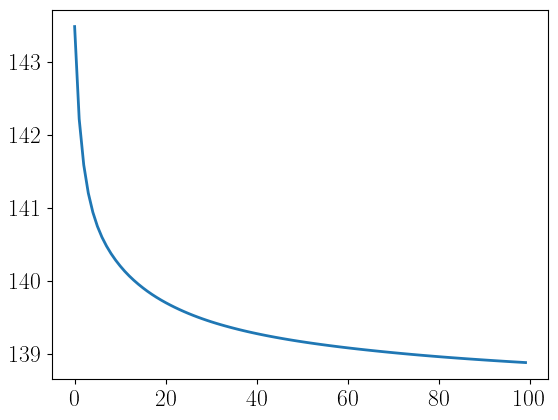

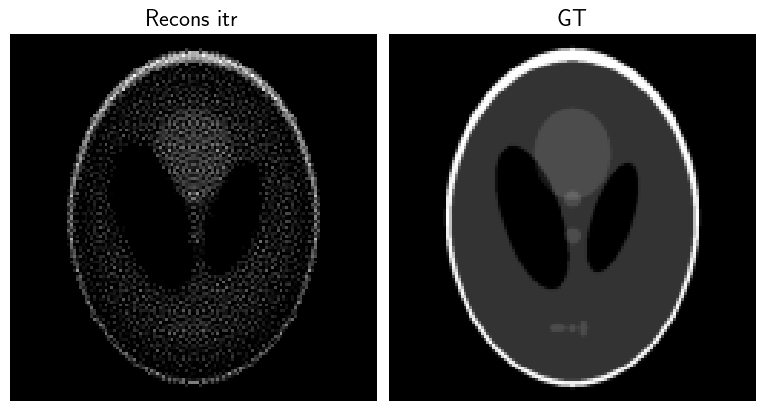

In [48]:
# Define Fidelity
fidelity = dinv.optim.data_fidelity.L2()

# Define Prior
prior = dinv.optim.L1Prior()

# Define optimizer
opt = dinv.optim.optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=fidelity,
    max_iter=100,
    crit_conv="residual",
    thres_conv=1e-4,
    early_stop=True,
    params_algo={"stepsize": 1.0, "lambda": 0.1}
)
## Run
u_hat, metrics = opt(y, tomo_exp, compute_metrics=True)

print(f'Reconstruction experiment')
print(f' MSE={MSE(u_hat, u_SL_small).item():.4f}\n PSNR={PSNR(u_hat, u_SL_small).item():.2f}\n SSIM={SSIM(u_hat, u_SL_small).item():.2f}\n')

plt.plot(metrics['cost'][0])
dinv.utils.plot([u_hat, u_SL_small], ['Recons itr', 'GT'], figsize=(12,4))

**TASK 2: Hyperparameter search**

Run the algorithms above. Play with the `stepsize`, `lambda` and `max_iter` hyperparameters to see how they affect the reconstruction. Does running it for more iterations always make the image better?

_Use code below to make see the differences in terms of MSE, PSNR and SSIM changing the parameters_

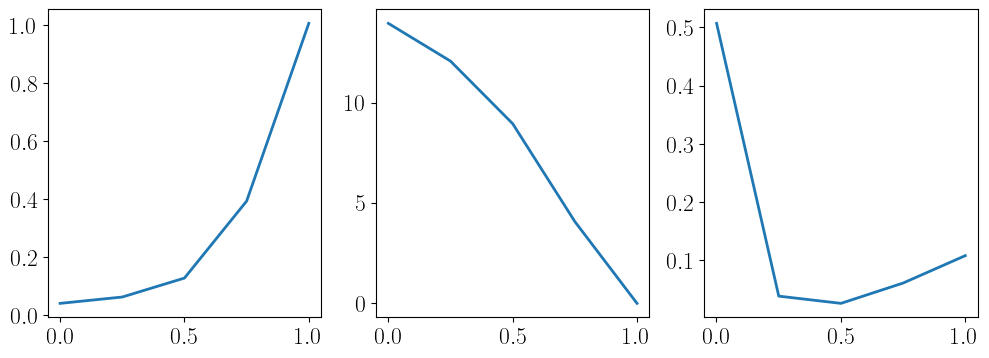

In [49]:
MSE_list = []
PSNR_list = []
SSIM_list = []
par_list = np.linspace(1e-3, 1, num=5)

for par in par_list:
    opt = dinv.optim.optim_builder(iteration="GD", prior=prior, data_fidelity=fidelity, \
                                    max_iter=100, crit_conv='residual', thres_conv=1e-4, early_stop=True, \
                                    params_algo={"stepsize": par}
                                  )
    u_hat = opt(y, tomo_exp)

    MSE_list.append(MSE(u_hat, u_SL_small).cpu().item())
    PSNR_list.append(PSNR(u_hat, u_SL_small).cpu().item())
    SSIM_list.append(SSIM(u_hat, u_SL_small).cpu().item())

fig, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].plot(par_list, MSE_list)
axs[1].plot(par_list, PSNR_list)
axs[2].plot(par_list, SSIM_list)
plt.show()

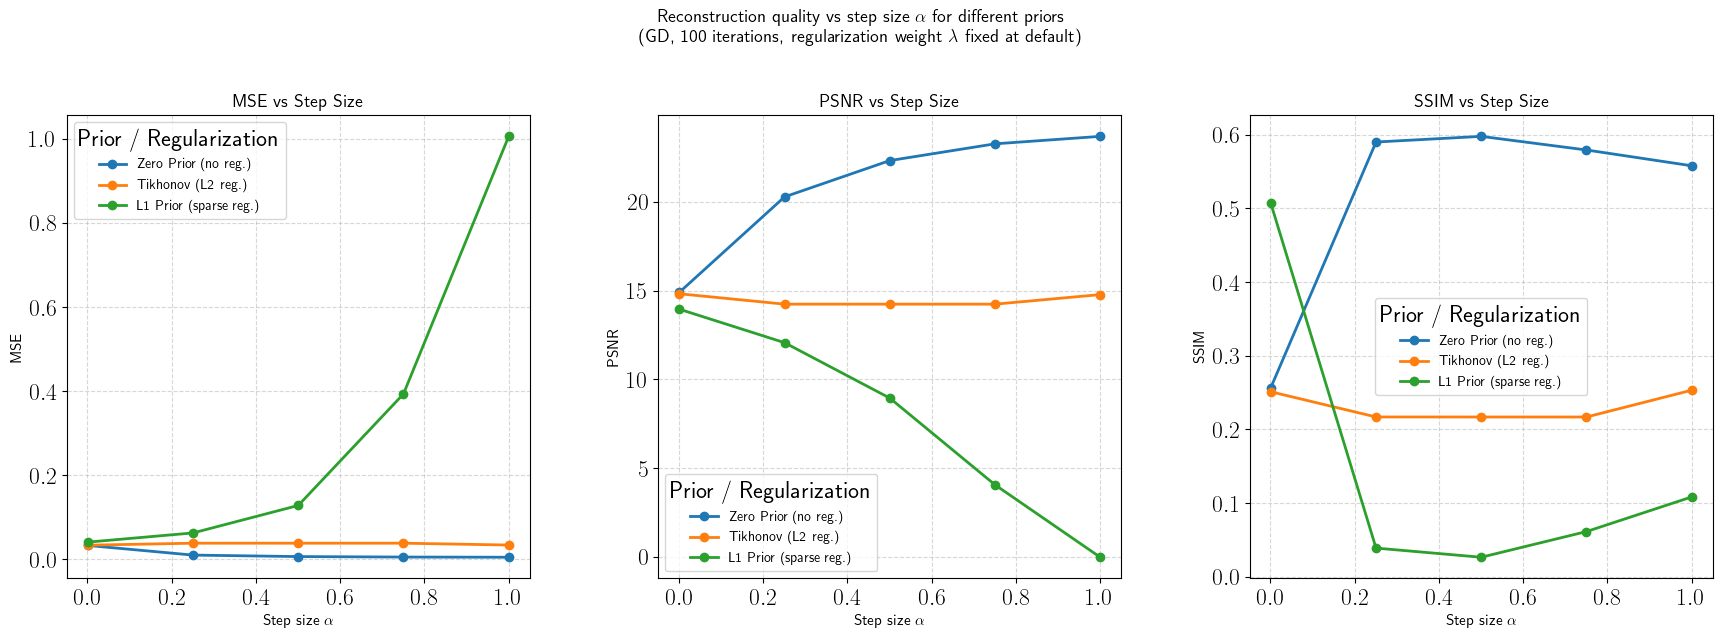

In [50]:
priors = {
    "Zero Prior (no reg.)":   dinv.optim.prior.ZeroPrior(),
    "Tikhonov (L2 reg.)":     dinv.optim.Tikhonov(),
    "L1 Prior (sparse reg.)": dinv.optim.L1Prior(),
}

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
# Force square axes
for ax in axs:
    ax.set_aspect('auto')
    ax.set_box_aspect(1)

par_list = np.linspace(1e-3, 1, num=5)

for name, prior in priors.items():
    MSE_list, PSNR_list, SSIM_list = [], [], []
    for par in par_list:
        opt = dinv.optim.optim_builder(
            iteration="GD", prior=prior, data_fidelity=fidelity,
            max_iter=100, crit_conv='residual', thres_conv=1e-4,
            early_stop=True, params_algo={"stepsize": par}
        )
        u_hat = opt(y, tomo_exp)
        MSE_list.append(MSE(u_hat, u_SL_small).cpu().item())
        PSNR_list.append(PSNR(u_hat, u_SL_small).cpu().item())
        SSIM_list.append(SSIM(u_hat, u_SL_small).cpu().item())

    axs[0].plot(par_list, MSE_list,  marker='o', linewidth=2, markersize=6, label=name)
    axs[1].plot(par_list, PSNR_list, marker='o', linewidth=2, markersize=6, label=name)
    axs[2].plot(par_list, SSIM_list, marker='o', linewidth=2, markersize=6, label=name)

# MSE
axs[0].set_title("MSE vs Step Size", fontsize=13, fontweight='bold')
axs[0].set_xlabel("Step size $\\alpha$", fontsize=11)
axs[0].set_ylabel("MSE", fontsize=11)
axs[0].legend(title="Prior / Regularization", fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.5)

# PSNR
axs[1].set_title("PSNR vs Step Size", fontsize=13, fontweight='bold')
axs[1].set_xlabel("Step size $\\alpha$", fontsize=11)
axs[1].set_ylabel("PSNR", fontsize=11)
axs[1].legend(title="Prior / Regularization", fontsize=10)
axs[1].grid(True, linestyle='--', alpha=0.5)

# SSIM
axs[2].set_title("SSIM vs Step Size", fontsize=13, fontweight='bold')
axs[2].set_xlabel("Step size $\\alpha$", fontsize=11)
axs[2].set_ylabel("SSIM", fontsize=11)
axs[2].legend(title="Prior / Regularization", fontsize=10)
axs[2].grid(True, linestyle='--', alpha=0.5)

fig.suptitle(
    "Reconstruction quality vs step size $\\alpha$ for different priors\n"
    "(GD, 100 iterations, regularization weight $\\lambda$ fixed at default)",
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.savefig("stepsizecompar.png", bbox_inches='tight', dpi=300)
plt.show()

**Optional TASK: Construction A**
- Assembly the matrix $\mathbf{A}$ associated to the Radon transform (use a small `image_size` and a sparse geometry at first).
- Compute the SVD observing the decay of its singular values.

In [51]:
N = 30
N_angles = 30
theta = np.linspace(0, 180, N_angles, endpoint=False)
theta = torch.tensor(theta).to(device)
tomoSVD = dinv.physics.Tomography(angles=theta, img_width=N, circle=circle, device=device)

temp = tomoSVD(torch.zeros((1,1,N,N)).to(device))
M = torch.numel(temp)

In [52]:
A_mat = torch.zeros((M, N*N)).to(device)

for i in range(N*N):
  e_i = torch.zeros(N*N).to(device)
  e_i[i] = 1
  e_i = e_i.view(1,1,N,N)
  A_mat[:, i] = torch.reshape(tomoSVD(e_i), (M,))

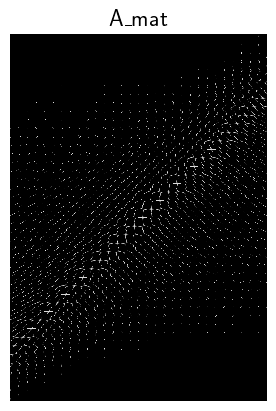

In [53]:
dinv.utils.plot(A_mat.unsqueeze(0), ['A_mat'], figsize=(6,4))

In [54]:
S = torch.linalg.svdvals(A_mat)

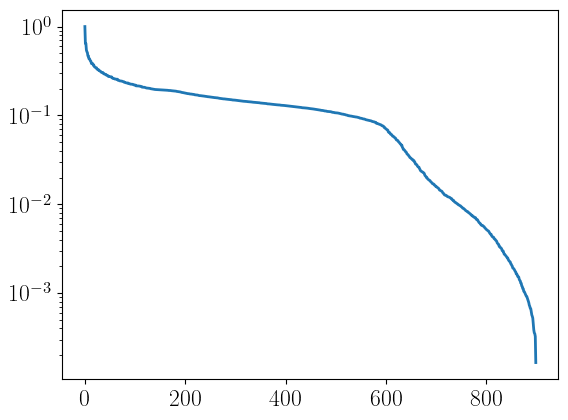

In [55]:
plt.semilogy(S.cpu().numpy())
plt.show()

In [56]:
# TASK: observe the decay of the singular values in case of Radon, limited-angle Radon, sparse-angle Radon

# CT LAB: Simulating and Reconstructiong Tomography Data

Authors: L. Calatroni, A. Sebastiani (MaLGa, Unige)

Mini-course "Computational Imaging & Learning" - MSc in Data Science, University of Padua, Italy.

In the previous lab, we solved the inverse problem using **Model-Based Reconstruction**. 
We explicitly defined a regularization function and minimized a cost function. 
While mathematically rigorous, these hand-crafted priors often fail to capture the complex, high-frequency textures.

In this lab, we transition to **learned regularisation functionals**. Instead of manually defining the regularizaer, we will learn the prior distribution implicitly from data.

We will explore **Plug-and-Play (PnP) Priors**: We replace the proximal operator of the regularizer with a pre-trained deep denoising neural network (e.g., DRUNet). This is a hybrid approach that combines known physics with learned image statistics.

In [57]:
import deepinv as dinv
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
from pathlib import Path
from torchvision import transforms, datasets

from deepinv.optim.prior import Prior, PnP
from deepinv.optim.optimizers import optim_builder
from deepinv.training import test
from deepinv.models import DnCNN

# Set the global random seed from pytorch to ensure reproducibility of the example.
torch.manual_seed(42)

# Specify the device (to use GPU on colab, first change the runtime to T4 GPU)
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

# Use parallel dataloader if using a GPU to fasten training.
num_workers = 5 if torch.cuda.is_available() else 0

Selected GPU 0 with 4796.625 MiB free memory


In [58]:
class GaussianNoiseCT(dinv.physics.GaussianNoise):
  def __init__(
        self,
        sigma: float | torch.Tensor = 0.1,
        rng: torch.Generator | None = None,
    ):
        super().__init__(sigma=sigma, rng=rng)

  def forward(self, x, sigma=None, seed=None, **kwargs):
        self.update_parameters(sigma=sigma, **kwargs)
        self.to(x.device)
        return (
            x
            + torch.max(torch.abs(x))*self.randn_like(x, seed=seed)
            * self.sigma[(...,) + (None,) * (x.dim() - 1)]
        )

# **Create the Physics: Radon Transform - Computed Tomography**

$$ \begin{aligned} \mathbf{y}(\boldsymbol{\theta},\rho) &= \int_{L_{\boldsymbol{\theta},\rho}}~u~d\sigma
\end{aligned} \qquad \boldsymbol{\theta} \in \R^2,~ \| \boldsymbol{\theta}\|=1, \quad \rho \in \mathbb{R}_+$$

($\mathbf{y}$ is usually referred to as the *sinogram* of $u$ and $L_{\boldsymbol{\theta},\rho} =  \left\{ \mathbf{x}: \mathbf{x}\cdot \boldsymbol{\theta} = \rho \right\}$)

In [59]:
noise_level_img = 0.1  # Gaussian Noise standard deviation for the degradation

angles = torch.tensor(np.linspace(0, 180, 30, endpoint=False)).to(device)

physics = dinv.physics.Tomography(
    img_width=28,
    angles=angles,
    circle=False,
    device=device,
    noise_model=GaussianNoiseCT(sigma=noise_level_img)
)

# **Create a dataset**

Next, we create a supervised dataset for the tomography problem by constructing
$$ \{(y_i,u_i)\}_{i=1}^N, \qquad u_i \text{: an image from dataset,}\quad y_i = \mathcal{R}u_i +\epsilon_i $$

Hint: use a rather small sample size $N$ to guarantee reasonable training times.

In [60]:
# Import the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

Train_dataset = datasets.MNIST(root="../datasets/", train=True, transform=transform, download=True)
Test_dataset = datasets.MNIST(root="../datasets/", train=False, transform=transform, download=True)

# Create a supervised dataset of simulated measurements

# Specify the (maximum) size of the train and test sets
n_train_max = (250 if torch.cuda.is_available() else 50)  # number of images used for training
n_test_max = (50 if torch.cuda.is_available() else 10)  # number of images used for testing

# Set the path to save the datasets
BASE_DIR = Path(".")
measurement_dir = BASE_DIR / "dataset"

deepinv_datasets_path = dinv.datasets.generate_dataset(
    train_dataset=Train_dataset,
    test_dataset=Test_dataset,
    physics=physics,
    device=device,
    save_dir=measurement_dir,
    train_datapoints=n_train_max,
    test_datapoints=n_test_max,
    num_workers=num_workers,
    dataset_filename="tomo"
)

train_dataset = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path, train=True)
test_dataset = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path, train=False)

/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/datasets/datagenerator.py:642: UserWarning: Dataset dataset/tomo0.h5 already exists, this will close and overwrite the previous dataset.
  warn(


Dataset has been saved at dataset/tomo0.h5


/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/utils/plotting.py:439: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.2, wspace=0.2)


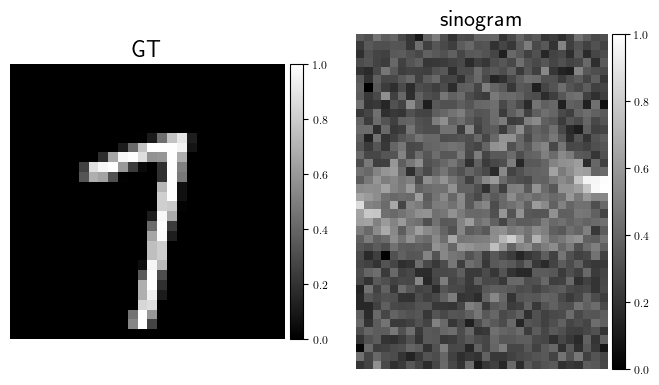

In [61]:
# Vizualize sample images from the dataset
select_image = 42
dinv.utils.plot([train_dataset[select_image][0], train_dataset[select_image][1]], ['GT', 'sinogram'], figsize=(8,4), cbar=True)

# **Variational regularisation techniques**

Choose a regularisation functional $\phi: \mathbb{R}^{n^2}\rightarrow \mathbb{R}$ and a parameter $\lambda >0 $ and solve
$$ u_\lambda \in \arg\min_{u \in \mathbb{R}^{n^2}} \left\{ \frac{1}{2}\| A u-y\|^2 + \lambda \phi(u)\right\}$$

/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/training/trainer.py:549: UserWarning: Update progress bar frequency of 1 may slow down training on GPU. Consider setting freq_update_progress_bar > 1.
  warnings.warn(
Test:  98%|█████████▊| 49/50 [00:18<00:00,  2.69it/s, PSNR=15.1, PSNR no learning=12.5]

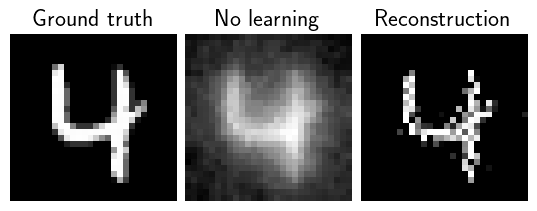

Test: 100%|██████████| 50/50 [00:18<00:00,  2.64it/s, PSNR=15.1, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 15.147 +- 1.786


{'PSNR no learning': 12.450964698791504,
 'PSNR no learning_std': 1.3451889141349176,
 'PSNR': 15.146677684783935,
 'PSNR_std': 1.7858004235689768}

In [62]:
# Select the data fidelity term (the first part of the functional to be minimized)
data_fidelity = dinv.optim.data_fidelity.L2()

# Specify the custom prior R
prior = dinv.optim.L1Prior()

# Specific parameters for restoration with the given prior (Note that these parameters have not been optimized here)
params_algo = {"stepsize": 1., "lambda": 0.05}

# Instantiate the algorithm class to solve the IP problem
modelVAR = optim_builder(
    iteration="PGD", # proximal gradient descent
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    params_algo=params_algo,
    early_stop=True,
    max_iter=500,
    crit_conv="cost",
    thres_conv=1e-5,
    backtracking=False,
    verbose=False,
)

# To get its 'average performances' we apply it to all the elements of the test set and take an average

batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelVAR,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images = True,
)

**********************************************************
**TASK 2: Explore other regularization choices**

Explore alternative choices for $\phi$. Have a look at https://deepinv.github.io/deepinv/api/stubs/deepinv.optim.Prior.html#deepinv.optim.Prior


**********************************************************

Test:  98%|█████████▊| 49/50 [13:02<00:16, 16.10s/it, PSNR=15, PSNR no learning=12.5]  

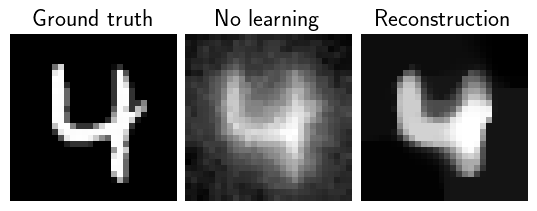

Test: 100%|██████████| 50/50 [13:02<00:00, 15.65s/it, PSNR=15, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 15.003 +- 1.505


{'PSNR no learning': 12.450964736938477,
 'PSNR no learning_std': 1.3451889580625607,
 'PSNR': 15.002851886749268,
 'PSNR_std': 1.5045766032298267}

In [63]:
# Select the data fidelity term (the first part of the functional to be minimized)
data_fidelity = dinv.optim.data_fidelity.L2()

# Check the TV prior (check https://deepinv.github.io/deepinv/auto_examples/optimization/demo_TV_minimisation.html )
prior = dinv.optim.TVPrior()

# Specific parameters for restoration with the given prior (Note that these parameters have not been optimized here)
params_algo = {"stepsize": 1., "lambda": 0.05}

# Instantiate the algorithm class to solve the IP problem
modelVAR = optim_builder(
    iteration="PGD", # proximal gradient descent
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    params_algo=params_algo,
    early_stop=True,
    max_iter=500,
    crit_conv="cost",
    thres_conv=1e-5,
    backtracking=False,
    verbose=False,
)

# To get its 'average performances' we apply it to all the elements of the test set and take an average

batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelVAR,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images = True,
)

**********************************************************
**TASK (Optional): Parameter Tuning**

Find the best choice for the parameter $\lambda$ by means of a supervised strategy.

Define a pool of possible parameters $\{10^{-7},10^{-6.5},\ldots,10^{-1},10^{-0.5},1\}$ and, for each of them, evaluate the performance on the training set. Then, pick the best one and use it on the test set.



**********************************************************

## **Plug-and-Play 1: PGD with pre-trained denoiser**

Consider the Proximal Gradient Descent (PGD) method associated with the minimization of the functional $\frac{1}{2}\| Au-y \|^2 + \lambda \phi(f)$, namely
$$
\left\{
\begin{aligned}
z^{(k+1)} &= u^{(k)} - \tau A^\top(Au^{(k)}-y) \\
u^{(k+1)} &= \operatorname{prox}_{\tau \lambda \phi}(z^{(k+1)})
\end{aligned}
\right.
$$
and replace the proximal operator of $\tau \lambda \phi$ by a neural network $D_{\theta,\sigma}$, obtaining
$$
\left\{
\begin{aligned}
z^{(k+1)} &= u^{(k)} - \tau A^\top(Au^{(k)}-y) \\
u^{(k+1)} &= D_{\theta,\sigma}(z^{(k+1)})
\end{aligned}
\right.
$$
The network $D_{\theta,\sigma}$ (depending on some parameters $\theta$) plays the role of a denoiser, and in particular it is trained to remove Gaussian noise, i.e., to approximate the MMSE denoiser associated with the prior distribution corrupted by Gaussian noise with standard deviation $\sigma$.

Let us first consider a simple case in which $D_{\theta,\sigma}$ is a CNN that has been pre-trained on natural images.

Test:  98%|█████████▊| 49/50 [00:25<00:00,  2.05it/s, PSNR=13, PSNR no learning=12.5]  

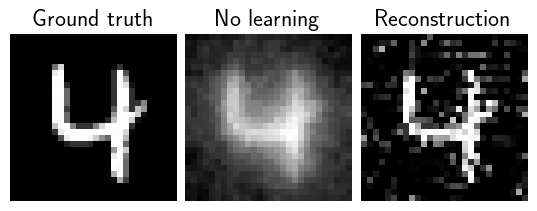

Test: 100%|██████████| 50/50 [00:25<00:00,  1.98it/s, PSNR=13, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 13.026 +- 1.418


{'PSNR no learning': 12.450964698791504,
 'PSNR no learning_std': 1.3451889141349176,
 'PSNR': 13.026289615631104,
 'PSNR_std': 1.4180184795322717}

In [64]:
from deepinv.models import DnCNN

sigma_PnP = 0.1  # matched to noise_level_img; tune between 0.01 and 0.2
params_algo = {"stepsize": 0.8, "g_param": sigma_PnP}
max_iter = 200
early_stop = True

denoiser = DnCNN(
    in_channels=1, # for greyscale images
    out_channels=1,
    pretrained="download",  # try also "download_lipschitz", it has convergence guarantees, but less expressivity
    device=device,
)
prior = PnP(denoiser=denoiser)

data_fidelity = dinv.optim.data_fidelity.L2()


# Instantiate the algorithm class to solve the IP problem
modelPnP = optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=data_fidelity,
    early_stop=early_stop,
    max_iter=max_iter,
    verbose=True,
    params_algo=params_algo,
)
modelPnP.eval() # set the model to evaluation mode. We do not require training here


# Set the data loader to test the regularizer
batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelPnP,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images = True,
)


# What is the effect of a different choice of sigma?

# **Plug-and-Play 2: let's also train the denoiser - your turn!**

We want to use in PGD a network specifically trained to denoise images from the our dataset.
To do so,
1.   we create another dataset $\{\tilde{u}_i,u_i\}_{i=1}^{N_{den}}$ such that $\tilde{u}_i = u_i + \tilde{\epsilon}_i$, where $\tilde{\epsilon}_i \sim \mathcal{N}(0,\sigma^2 I)$
2.   we define a denoiser $D_\theta$ as a CNN as above and train it, namely we choose its parameters $\theta$ so to minimize $$L_{den}(\theta) = \frac{1}{N_{den}} \sum_{i=1}^{N_{den}} \| D_\theta(\tilde{u}_i) - u_i\|^2$$
3.  we use the trained denoiser $ D_{\theta,\sigma}$ in place of the prox of a regularization functional in any PnP scheme - e.g. PnP-PGD

Follow the steps below to implement this strategy.

In [65]:
# Part 1: dataset

denoiser_train = DnCNN(   # Try also UNet
    in_channels=1,
    out_channels=1,
    pretrained="download",
    device=device,
)

# Create a supervised dataset of simulated measurements

# Specify the (maximum) size of the train and test sets
n_train_max_PnP = (250 if torch.cuda.is_available() else 50)  # number of images used for training
n_test_max_PnP = (50 if torch.cuda.is_available() else 10)  # number of images used for testing

# Set the path to save the datasets
BASE_DIR = Path(".")
measurement_dir = BASE_DIR / "dataset"

# Define the physics: COMPLETE!
# Check https://deepinv.github.io/deepinv/api/stubs/deepinv.physics.Denoising.html

sigma_PnP = 0.05
noise_model_PnP = dinv.physics.GaussianNoise(sigma=sigma_PnP)
physics_PnP = dinv.physics.Denoising(noise_model=noise_model_PnP)

# Generate noisy dataset
deepinv_datasets_path_PnP = dinv.datasets.generate_dataset(
    train_dataset=Train_dataset,
    test_dataset=Test_dataset,
    physics=physics_PnP,
    device=device,
    save_dir=measurement_dir,
    train_datapoints=n_train_max_PnP,
    test_datapoints=n_test_max_PnP,
    num_workers=num_workers,
    dataset_filename="denoise",
)

train_dataset_PnP = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path_PnP, train=True)
test_dataset_PnP = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path_PnP, train=False)

/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/datasets/datagenerator.py:642: UserWarning: Dataset dataset/denoise0.h5 already exists, this will close and overwrite the previous dataset.
  warn(


Dataset has been saved at dataset/denoise0.h5


The model has 665921 trainable parameters


/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/training/trainer.py:1354: UserWarning: non_blocking_transfers=True but DataLoader.pin_memory=False; set pin_memory=True to overlap host-device copies with compute.
  self.setup_train()


Train epoch 0: TotalLoss=0.003, PSNR=25.432
Eval epoch 0: PSNR=26.022
Best model saved at epoch 1
Train epoch 1: TotalLoss=0.003, PSNR=26.019
Eval epoch 1: PSNR=26.039
Best model saved at epoch 2
Train epoch 2: TotalLoss=0.002, PSNR=26.469
Eval epoch 2: PSNR=27.492
Best model saved at epoch 3
Train epoch 3: TotalLoss=0.001, PSNR=28.904
Eval epoch 3: PSNR=30.326
Best model saved at epoch 4
Train epoch 4: TotalLoss=0.001, PSNR=30.785
Eval epoch 4: PSNR=31.715
Best model saved at epoch 5
Train epoch 5: TotalLoss=0.001, PSNR=31.43
Eval epoch 5: PSNR=32.459
Best model saved at epoch 6
Train epoch 6: TotalLoss=0.001, PSNR=32.7
Eval epoch 6: PSNR=33.323
Best model saved at epoch 7
Train epoch 7: TotalLoss=0.001, PSNR=32.93
Eval epoch 7: PSNR=33.689
Best model saved at epoch 8
Train epoch 8: TotalLoss=0.0, PSNR=33.722
Eval epoch 8: PSNR=34.177
Best model saved at epoch 9
Train epoch 9: TotalLoss=0.0, PSNR=33.859
Eval epoch 9: PSNR=34.181
Best model saved at epoch 10
Train epoch 10: TotalLoss=0

Test:   0%|          | 0/5 [00:00<?, ?it/s, PSNR=35.1, PSNR no learning=26]  

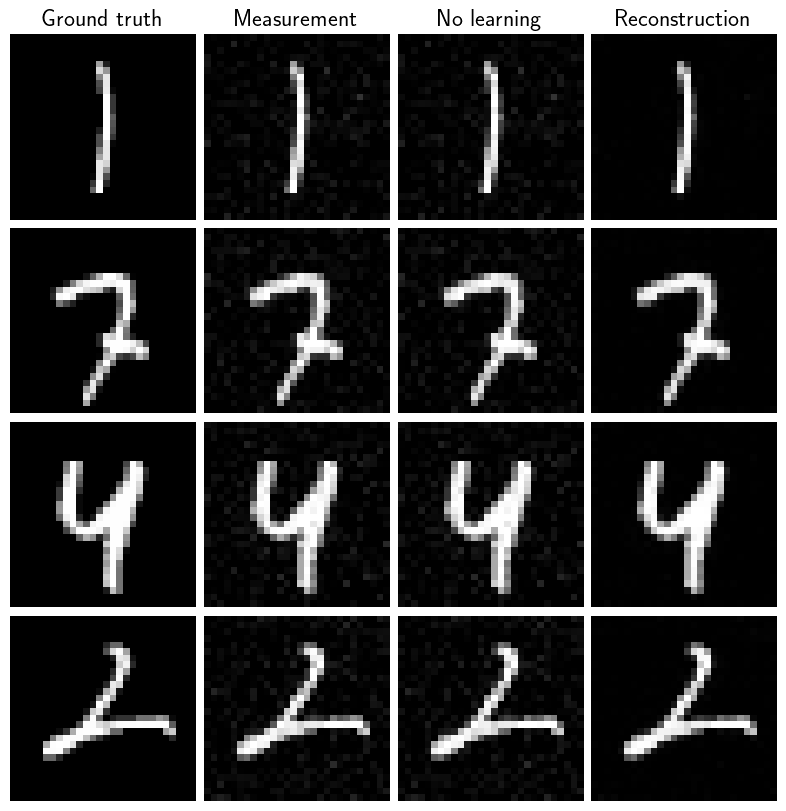

Test: 100%|██████████| 5/5 [00:00<00:00, 13.86it/s, PSNR=35.1, PSNR no learning=26]

Test results:
PSNR no learning: 26.028 +- 0.234
PSNR: 35.090 +- 1.381


DnCNN(
  (in_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_list): ModuleList(
    (0-17): 18 x Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (out_conv): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (nl_list): ModuleList(
    (0-18): 19 x ReLU()
  )
)

In [66]:
# Part 2: training

data_fidelity = dinv.optim.data_fidelity.L2()

# Set the dataloader for the training
batch_size=10
train_dataloader_PnP = DataLoader(train_dataset_PnP, batch_size=batch_size, num_workers=0, shuffle=False)
test_dataloader_PnP = DataLoader(test_dataset_PnP, batch_size=batch_size, num_workers=0, shuffle=False)

# Set the training algorithm
learning_rate = 1e-3
epochs = 20
optimizer = torch.optim.Adam(denoiser_train.parameters(), lr=learning_rate)
losses = [dinv.loss.SupLoss(metric=dinv.loss.metric.MSE())]

trainer_den = dinv.Trainer(
    model=denoiser_train,
    physics=physics_PnP,
    train_dataloader=train_dataloader_PnP,
    eval_dataloader=test_dataloader_PnP,
    epochs=epochs,
    losses=losses,
    optimizer=optimizer,
    device=device,
    verbose=True,
    show_progress_bar=False,
)

# Training
modelDenoiser = trainer_den.train()
test(
    model=denoiser_train,
    test_dataloader=test_dataloader_PnP,
    physics=physics_PnP,
    device=device,
    verbose=True,
    plot_images = True,
)

# Training is over: now let us use the trained model
modelDenoiser.eval()

**********************************************************
**TASK: Use your brand new denoiser! **

Use the trained denoiser within a simple PnP-PGD scheme.

Hint: since the prior is strong, you can use a small regularization parameter. This is encoded by selecting a large stepsize.


**********************************************************

Test:  98%|█████████▊| 49/50 [00:24<00:00,  2.07it/s, PSNR=21.7, PSNR no learning=12.5]

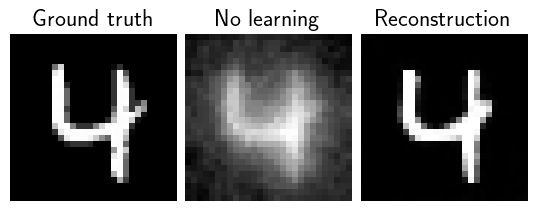

Test: 100%|██████████| 50/50 [00:24<00:00,  2.03it/s, PSNR=21.7, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 21.748 +- 1.830


{'PSNR no learning': 12.450964660644532,
 'PSNR no learning_std': 1.3451889269233979,
 'PSNR': 21.74787120819092,
 'PSNR_std': 1.830122843124155}

In [67]:
# Solution: Part 3

params_algo = {"stepsize": 1.0, "g_param": sigma_PnP}
max_iter = 200
early_stop = True

prior = PnP(denoiser=modelDenoiser)

data_fidelity = dinv.optim.data_fidelity.L2()

# Instantiate the algorithm class to solve the IP problem: COMPLETE
modelPnP_new = optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=data_fidelity,
    early_stop=early_stop,
    max_iter=max_iter,
    verbose=True,
    params_algo=params_algo,
)
modelPnP_new.eval() # set the model to evaluation mode. We do not require training here

# Set the data loader to test the regularizer: COMPLETE
batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelPnP_new,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images=True,
)